# Verkeersongevallen in België 2017–2024
## Exploratory Data Analysis
**Databron:** Statbel — Geolocalisatie van de verkeersongevallen 2017-2024  
https://statbel.fgov.be/nl/open-data/geolocalisatie-van-de-verkeersongevallen-2017-2024

## 1. Imports & configuratie

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='Blues_d')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
pd.set_option('display.max_columns', None)

print('Libraries geladen ✓')

Libraries geladen ✓


## 2. Data inladen

In [3]:
df = pd.read_excel('../data/raw/OPENDATA_MAP_2017-2024.xlsx')

print(f'Aantal rijen:    {df.shape[0]:,}')
print(f'Aantal kolommen: {df.shape[1]}')
df.head()

Aantal rijen:    289,532
Aantal kolommen: 45


,DT_YEAR_COLLISION,DT_MONTH_COLLISION,DT_TIME,CD_NIS,TX_RGN_COLLISION_FR,TX_RGN_COLLISION_NL,TX_PROV_COLLISION_FR,TX_PROV_COLLISION_NL,TX_MUNTY_COLLISION_FR,TX_MUNTY_COLLISION_NL,MS_X_COORD,MS_Y_COORD,CD_CROSSWAY,TX_CROSSWAY_FR,TX_CROSSWAY_NL,CD_WEATHER,TX_WEATHER_FR,TX_WEATHER_NL,CD_ROAD_CONDITION,TX_ROAD_CONDITION_FR,TX_ROAD_CONDITION_NL,CD_BUILD_UP_AREA,TX_BUILD_UP_AREA_FR,TX_BUILD_UP_AREA_NL,CD_LIGHT_CONDITION,TX_LIGHT_CONDITION_FR,TX_LIGHT_CONDITION_NL,CD_ROAD_TYPE,CD_ROAD_TYPE_FR,CD_ROAD_TYPE_NL,CD_CLASS_ACCIDENTS,TX_CLASS_ACCIDENTS_FR,TX_CLASS_ACCIDENTS_NL,CD_ROAD_USR_TYPE1,TX_ROAD_USR_TYPE1_FR,TX_ROAD_USR_TYPE1_NL,CD_ROAD_USR_TYPE2,TX_ROAD_USR_TYPE2_FR,TX_ROAD_USR_TYPE2_NL,CD_COLLISION_TYPE,TX_COLLISON_TYPE_FR,TX_COLLISION_TYPE_NL,CD_OBSTACLES,TX_OBSTACLES_FR,TX_OBSTACLES_NL
0,2017,1,1,21015,Région de Bruxelles-Capitale,Brussels Hoofdstedelijk Gewest,NaN,NaN,Schaerbeek,Schaarbeek,149732.990000,172425.510000,1,Carrefour,Op Kruispunt,1,Normales,Normaal,1,Sec,Droog,1,En agglomération,binnen bebouwde kom,3,"Nuit, éclairage public présent et allumé","Nacht, openbare verlichting aanwezig en ontstoken",2,Route communale,Gemeenteweg,4,Avec blessé(s) leger(s),met lichtgewonden,9,Voiture,personenauto,8,Piéton,Voetganger,5,Avec un piéton,Met een voetganger,0,Pas d’obstacle,Geen hindernis
1,2017,1,0,11002,Région flamande,Vlaams Gewest,Province d’Anvers,Provincie Antwerpen,Anvers,Antwerpen,152268.069000,209633.121000,1,Carrefour,Op Kruispunt,1,Normales,Normaal,1,Sec,Droog,1,En agglomération,binnen bebouwde kom,3,"Nuit, éclairage public présent et allumé","Nacht, openbare verlichting aanwezig en ontstoken",2,Route communale,Gemeenteweg,4,Avec blessé(s) leger(s),met lichtgewonden,3,Bicyclette,Fiets,9,Voiture,personenauto,2,Entre 2 conducteurs: Collision frontale,Tussen 2 bestuurders: Frontale botsing,0,Pas d’obstacle,Geen hindernis
2,2017,1,1,71016,Région flamande,Vlaams Gewest,Province de Limbourg,Provincie Limburg,Genk,Genk,228984.996050,184597.362066,1,Carrefour,Op Kruispunt,9,"Inconnues, indéterminées",Onbekend,9,"Inconnu, indéterminé",Onbekend,1,En agglomération,binnen bebouwde kom,9,"Inconnu, indéterminé",Onbekend,3,Route régionale,Gewestweg,4,Avec blessé(s) leger(s),met lichtgewonden,9,Voiture,personenauto,9,Voiture,personenauto,3,Entre 2 conducteurs: Par l'arrière,Tussen 2 bestuurders: Langs achteren,0,Pas d’obstacle,Geen hindernis
3,2017,1,10,21001,Région de Bruxelles-Capitale,Brussels Hoofdstedelijk Gewest,NaN,NaN,Anderlecht,Anderlecht,145322.270000,168391.870000,1,Carrefour,Op Kruispunt,1,Normales,Normaal,2,"Humide, mouillé, flaques","Nat, plassen",1,En agglomération,binnen bebouwde kom,1,Jour,Dag,2,Route communale,Gemeenteweg,4,Avec blessé(s) leger(s),met lichtgewonden,9,Voiture,personenauto,9,Voiture,personenauto,4,Entre 2 conducteurs: Par le côté (avant/derriè...,Tss. 2 best.: langs opzij (voor-/achterkant-fl...,0,Pas d’obstacle,Geen hindernis
4,2017,1,7,11035,Région flamande,Vlaams Gewest,Province d’Anvers,Provincie Antwerpen,Ranst,Ranst,172211.143282,214752.568641,2,Hors carrefour,Buiten Kruispunt,1,Normales,Normaal,1,Sec,Droog,2,Hors agglomération,buiten bebouwde kom,1,Jour,Dag,1,Autoroute,Autosnelweg,4,Avec blessé(s) leger(s),met lichtgewonden,9,Voiture,personenauto,9,Voiture,personenauto,3,Entre 2 conducteurs: Par l'arrière,Tussen 2 bestuurders: Langs achteren,0,Pas d’obstacle,Geen hindernis


## 3. Data verkenning

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 289532 entries, 0 to 289531
Data columns (total 45 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   DT_YEAR_COLLISION      289532 non-null  int64  
 1   DT_MONTH_COLLISION     289532 non-null  int64  
 2   DT_TIME                289532 non-null  int64  
 3   CD_NIS                 289532 non-null  int64  
 4   TX_RGN_COLLISION_FR    289532 non-null  object 
 5   TX_RGN_COLLISION_NL    289532 non-null  object 
 6   TX_PROV_COLLISION_FR   259510 non-null  object 
 7   TX_PROV_COLLISION_NL   259510 non-null  object 
 8   TX_MUNTY_COLLISION_FR  289532 non-null  object 
 9   TX_MUNTY_COLLISION_NL  289532 non-null  object 
 10  MS_X_COORD             253651 non-null  float64
 11  MS_Y_COORD             253651 non-null  float64
 12  CD_CROSSWAY            289532 non-null  int64  
 13  TX_CROSSWAY_FR         289532 non-null  object 
 14  TX_CROSSWAY_NL         289532 non-nu

In [5]:
# Missende waarden
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print('Kolommen met missende waarden:')
for col, n in missing.items():
    print(f'  {col}: {n:,} ({n/len(df)*100:.1f}%)')

Kolommen met missende waarden:
  MS_X_COORD: 35,881 (12.4%)
  MS_Y_COORD: 35,881 (12.4%)
  TX_PROV_COLLISION_FR: 30,022 (10.4%)
  TX_PROV_COLLISION_NL: 30,022 (10.4%)


## 4. Data cleaning

In [6]:
# Tijdkolom parsen (formaat: HHMM als integer of string)
df['DT_TIME'] = df['DT_TIME'].astype(str).str.zfill(4)
df['hour'] = pd.to_numeric(df['DT_TIME'].str[:2], errors='coerce')

# Provincie: missende waarden opvullen
df['provincie'] = df['TX_PROV_COLLISION_NL'].fillna('Onbekend')

# Veelgebruikte kolommen hernoemen
df = df.rename(columns={
    'DT_YEAR_COLLISION':     'jaar',
    'DT_MONTH_COLLISION':    'maand',
    'TX_MUNTY_COLLISION_NL': 'gemeente',
    'TX_RGN_COLLISION_NL':   'gewest',
    'TX_CLASS_ACCIDENTS_NL': 'ernst',
    'TX_WEATHER_NL':         'weer',
    'TX_LIGHT_CONDITION_NL': 'licht',
    'CD_ROAD_TYPE_NL':       'wegtype',
    'MS_X_COORD':            'x',
    'MS_Y_COORD':            'y'
})

# Maandnamen
maanden = {1:'Jan',2:'Feb',3:'Mrt',4:'Apr',5:'Mei',6:'Jun',
           7:'Jul',8:'Aug',9:'Sep',10:'Okt',11:'Nov',12:'Dec'}
df['maand_naam'] = df['maand'].map(maanden)

print('Cleaning klaar ✓')
print(f'Dataset: {len(df):,} rijen')

Cleaning klaar ✓
Dataset: 289,532 rijen


## 5. Business vraag 1 — Wanneer gebeuren de meeste ongevallen?

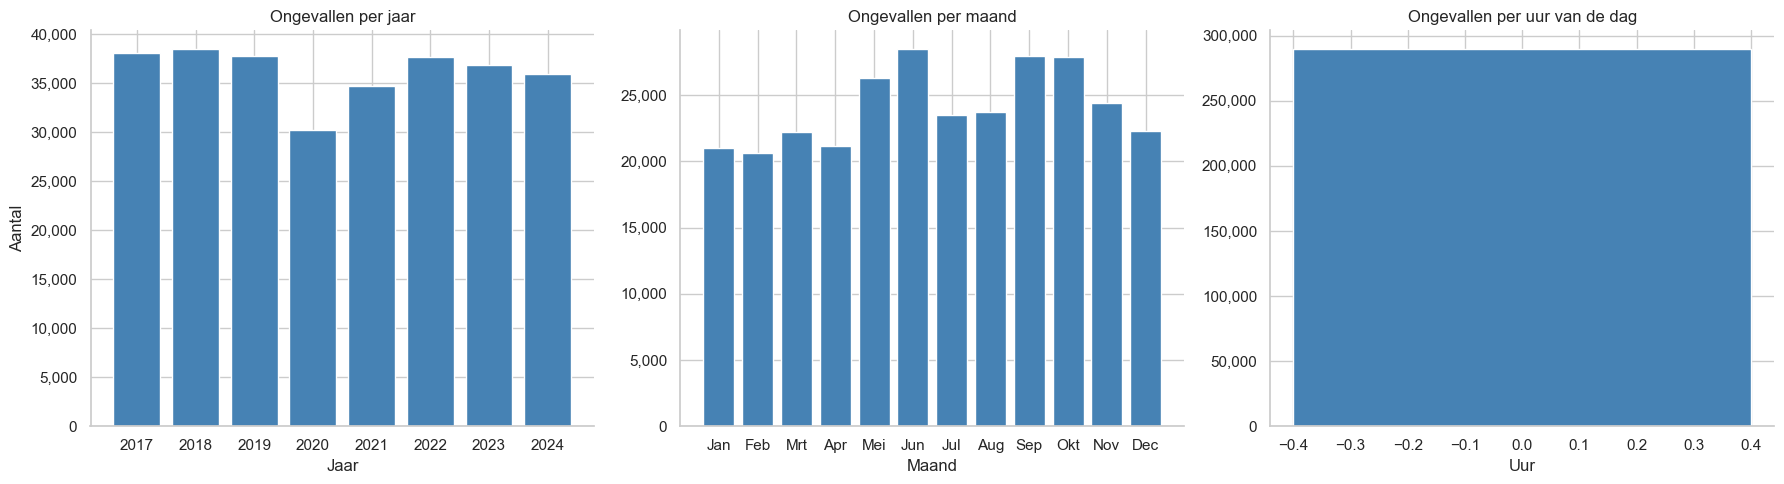

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Per jaar
jaar_counts = df['jaar'].value_counts().sort_index()
axes[0].bar(jaar_counts.index, jaar_counts.values, color='steelblue')
axes[0].set_title('Ongevallen per jaar')
axes[0].set_xlabel('Jaar')
axes[0].set_ylabel('Aantal')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# Per maand
maand_counts = df.groupby('maand').size()
axes[1].bar([maanden[m] for m in maand_counts.index], maand_counts.values, color='steelblue')
axes[1].set_title('Ongevallen per maand')
axes[1].set_xlabel('Maand')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# Per uur
uur_counts = df['hour'].dropna().astype(int).value_counts().sort_index()
axes[2].bar(uur_counts.index, uur_counts.values, color='steelblue')
axes[2].set_title('Ongevallen per uur van de dag')
axes[2].set_xlabel('Uur')
axes[2].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.tight_layout()
plt.savefig('../data/processed/plot_tijd.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Business vraag 2 — Welke provincies & gemeentes zijn het gevaarlijkst?

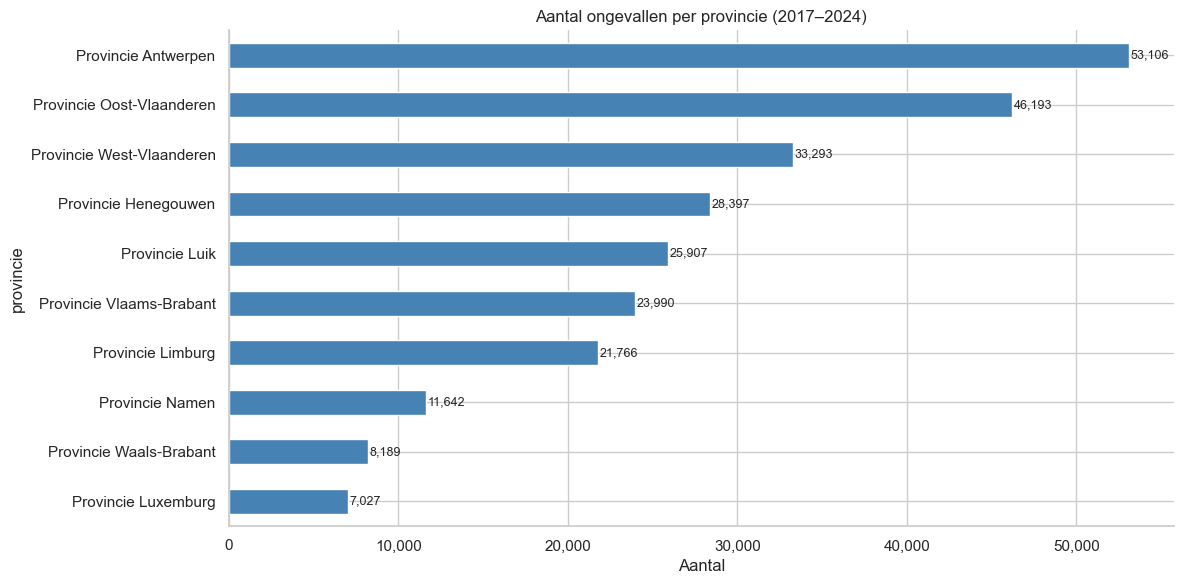

In [8]:
# Per provincie
prov_counts = df[df['provincie'] != 'Onbekend']['provincie'].value_counts()

fig, ax = plt.subplots(figsize=(12, 6))
prov_counts.plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Aantal ongevallen per provincie (2017–2024)')
ax.set_xlabel('Aantal')
ax.invert_yaxis()
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
for i, v in enumerate(prov_counts.values):
    ax.text(v + 100, i, f'{v:,}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('../data/processed/plot_provincie.png', dpi=150, bbox_inches='tight')
plt.show()

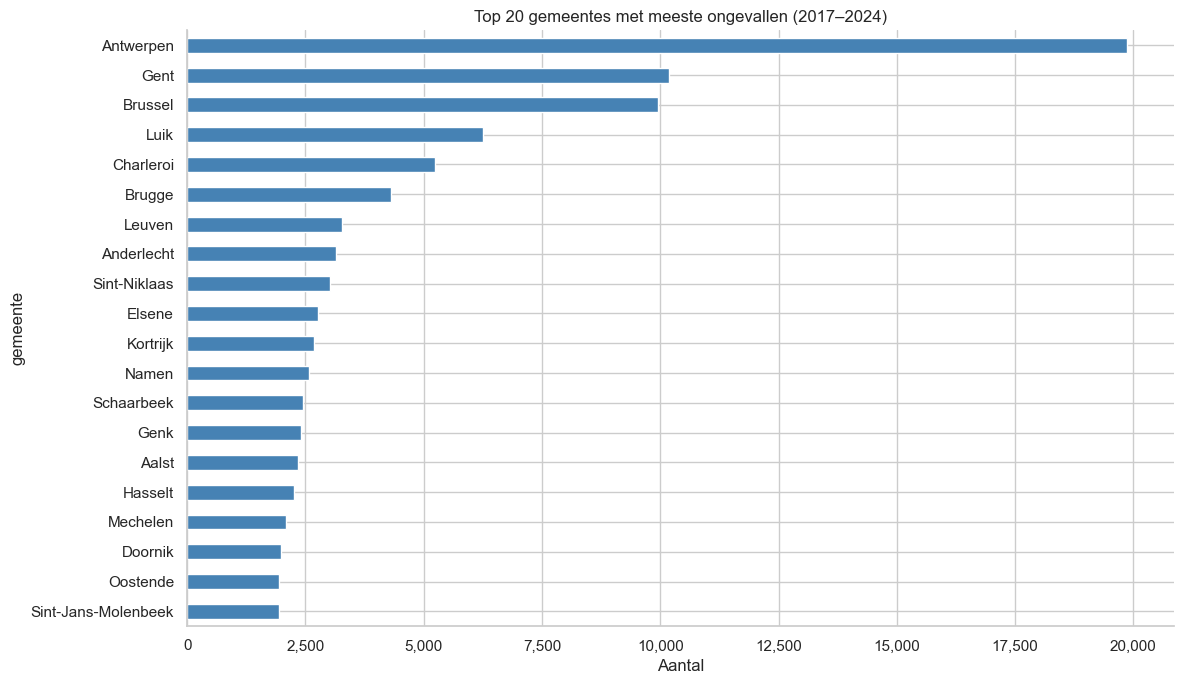

In [9]:
# Top 20 gemeentes
gem_counts = df['gemeente'].value_counts().head(20)

fig, ax = plt.subplots(figsize=(12, 7))
gem_counts.plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Top 20 gemeentes met meeste ongevallen (2017–2024)')
ax.set_xlabel('Aantal')
ax.invert_yaxis()
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.savefig('../data/processed/plot_gemeentes.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Business vraag 3 — Evolutie over de jaren per ernst

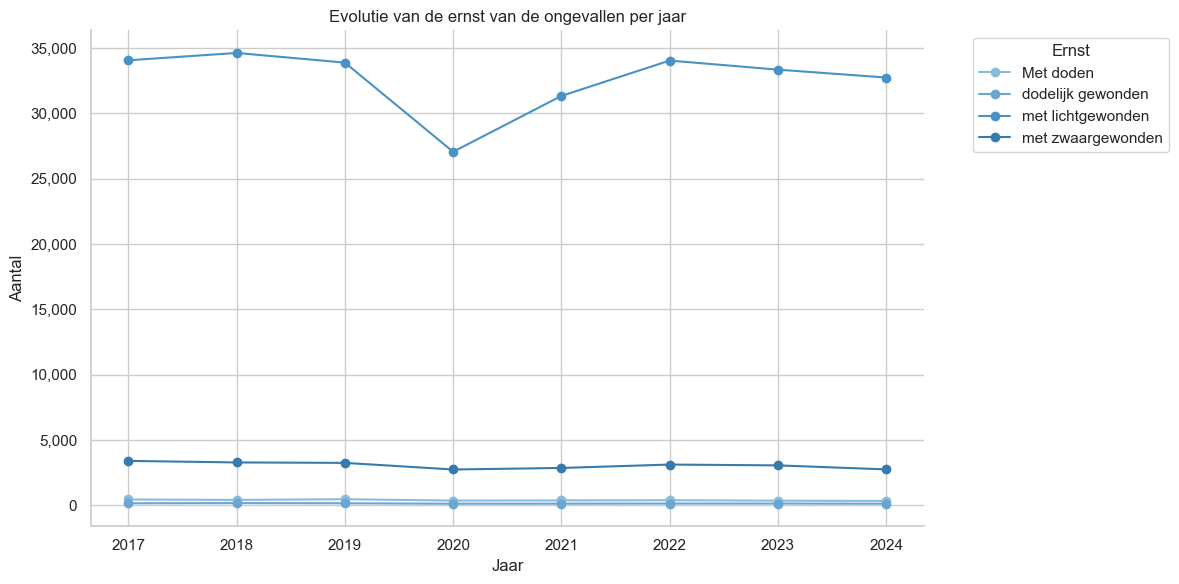

In [10]:
evolutie = df.groupby(['jaar', 'ernst']).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(12, 6))
evolutie.plot(ax=ax, marker='o')
ax.set_title('Evolutie van de ernst van de ongevallen per jaar')
ax.set_xlabel('Jaar')
ax.set_ylabel('Aantal')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.legend(title='Ernst', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('../data/processed/plot_evolutie.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Business vraag 4 — Wegtype & weersomstandigheden

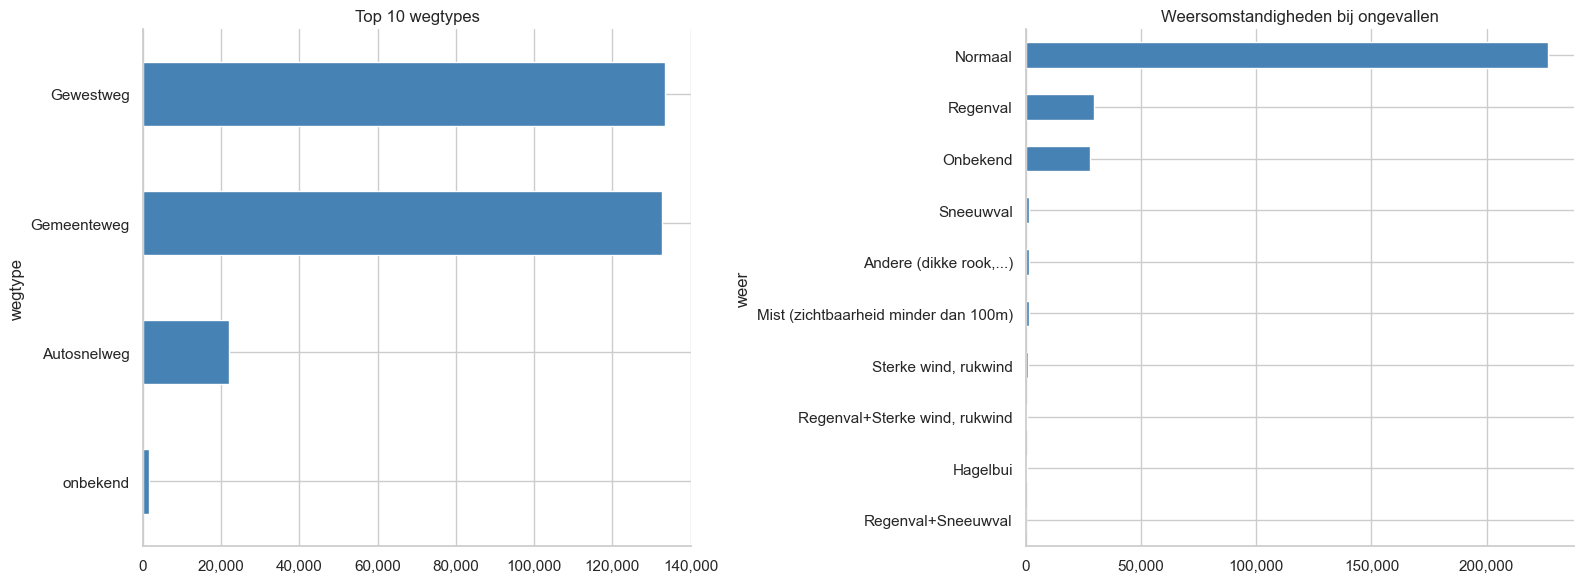

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Wegtype
wt = df['wegtype'].value_counts().head(10)
wt.plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Top 10 wegtypes')
axes[0].invert_yaxis()
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# Weersomstandigheden
wr = df['weer'].value_counts().head(10)
wr.plot(kind='barh', ax=axes[1], color='steelblue')
axes[1].set_title('Weersomstandigheden bij ongevallen')
axes[1].invert_yaxis()
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.tight_layout()
plt.savefig('../data/processed/plot_omstandigheden.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Business vraag 5 — Betrokken weggebruikers

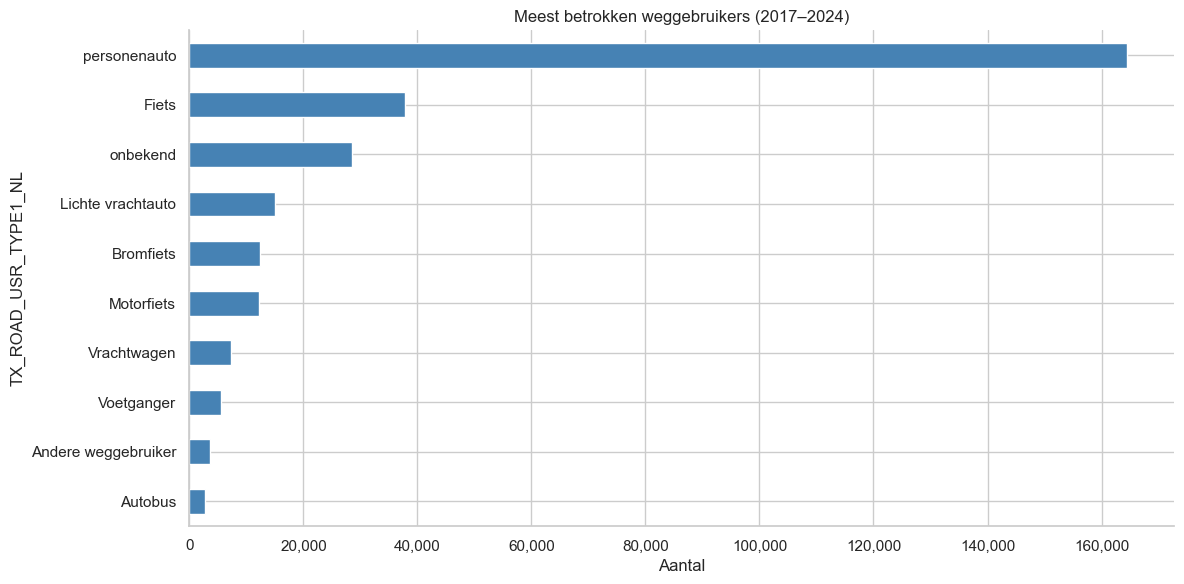

In [12]:
usr1 = df['TX_ROAD_USR_TYPE1_NL'].value_counts().head(10)

fig, ax = plt.subplots(figsize=(12, 6))
usr1.plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Meest betrokken weggebruikers (2017–2024)')
ax.set_xlabel('Aantal')
ax.invert_yaxis()
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.savefig('../data/processed/plot_weggebruikers.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Gecleande data opslaan

In [13]:
df.to_csv('../data/processed/ongevallen_cleaned.csv', index=False, encoding='utf-8-sig')
print(f'Opgeslagen: data/processed/ongevallen_cleaned.csv')
print(f'Rijen: {len(df):,} | Kolommen: {df.shape[1]}')

Opgeslagen: data/processed/ongevallen_cleaned.csv
Rijen: 289,532 | Kolommen: 48


## 11. Conclusies

> Vul hier je bevindingen in na het uitvoeren van de analyse:
> 
> - De piekuren voor verkeersongevallen zijn ...
> - De gevaarlijkste provincie is ...
> - Het aantal ongevallen over de jaren toont ...
> - Het meest betrokken wegtype is ...
> - De meest betrokken weggebruikers zijn ...